In [10]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("playground-series-s5e7/train.csv")

df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [11]:
def get_overview(data: pd.DataFrame) -> dict:
    '''데이터셋의 기본 개요 정보를 반환합니다.'''
    return {
        "행 개수": data.shape[0],
        "열 개수": data.shape[1],
        "컬럼명": list(data.columns),
        "수치형 컬럼": list(data.select_dtypes(include="number").columns),
        "범주형 컬럼": list(data.select_dtypes(exclude="number").columns),
    }

overview = get_overview(df)
for k, v in overview.items():
    print(f"{k}: {v}")

def get_missing_report(data: pd.DataFrame) -> pd.DataFrame:
    '''컬럼별 결측치 개수와 비율을 데이터프레임으로 반환합니다.'''
    missing_count = data.isnull().sum()
    missing_pct = (missing_count / len(data) * 100).round(2)
    report = pd.DataFrame({
        "결측치 개수": missing_count,
        "결측치 비율(%)": missing_pct
    })
    return report.sort_values("결측치 개수", ascending=False)

행 개수: 18524
열 개수: 9
컬럼명: ['id', 'Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Personality']
수치형 컬럼: ['id', 'Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
범주형 컬럼: ['Stage_fear', 'Drained_after_socializing', 'Personality']


/home/gowtflow/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gowtflow/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gowtflow/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gowtflow/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gowtflow/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing 

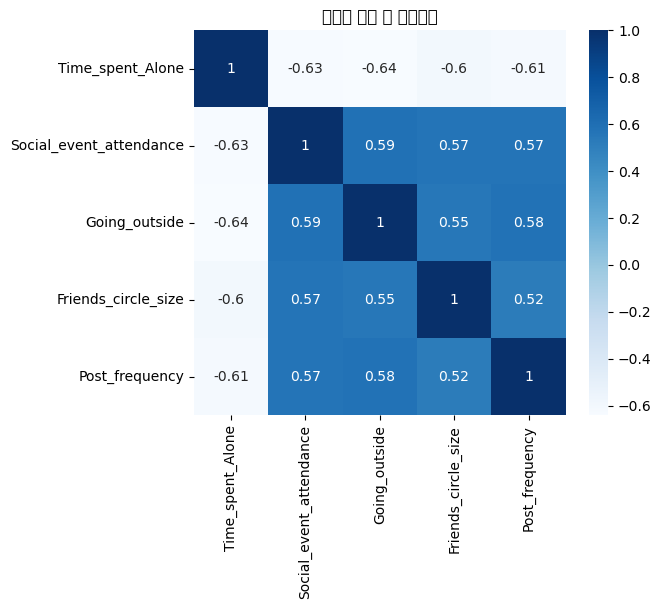

In [16]:
def plot_correlation_heatmap(data: pd.DataFrame):
    '''수치형 컬럼 간 상관관계를 히트맵으로 시각화합니다.'''
    numeric_df = data.select_dtypes(include="number")
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues", ax=ax)
    ax.set_title("수치형 변수 간 상관관계")
    return fig

%matplotlib inline
fig = plot_correlation_heatmap(df.drop(columns='id'))
plt.show()

In [24]:
def plot_distribution(data: pd.DataFrame, column: str):
    '''선택한 컬럼의 분포를 히스토그램으로 시각화합니다.'''
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.histplot(data[column], kde=True, ax=ax)
    ax.set_title(f"'{column}' Distribution")
    return fig

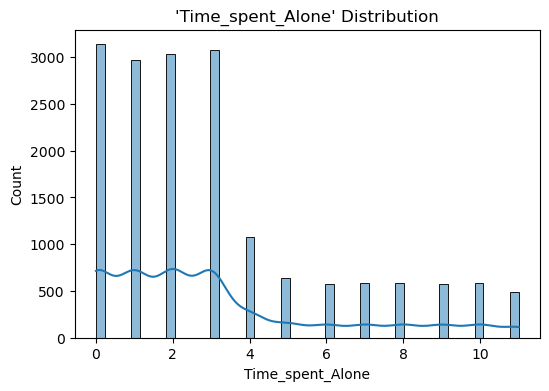

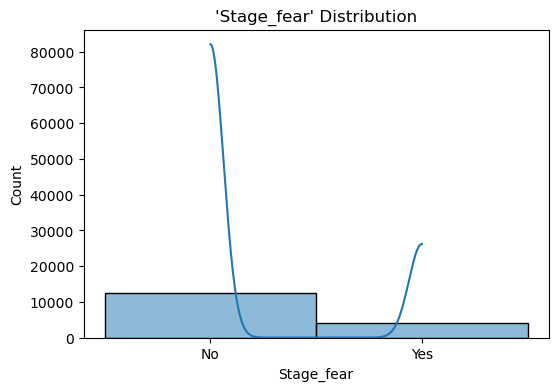

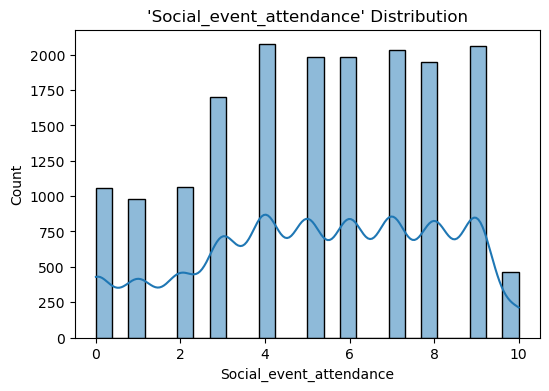

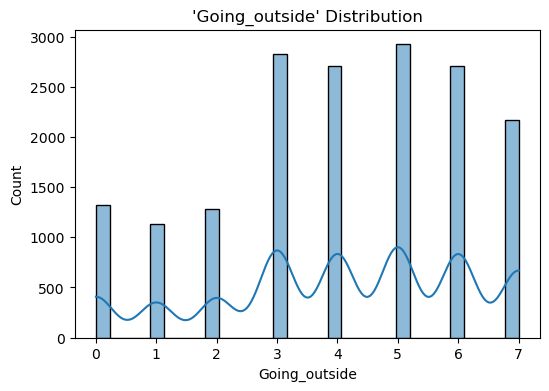

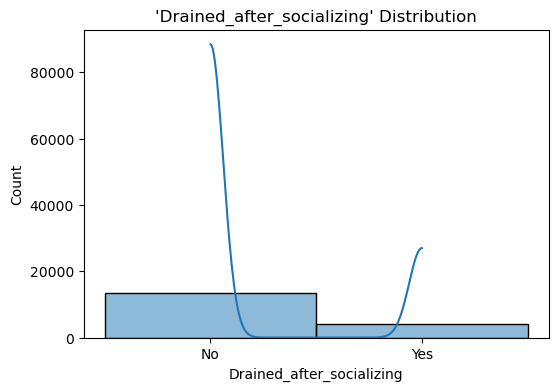

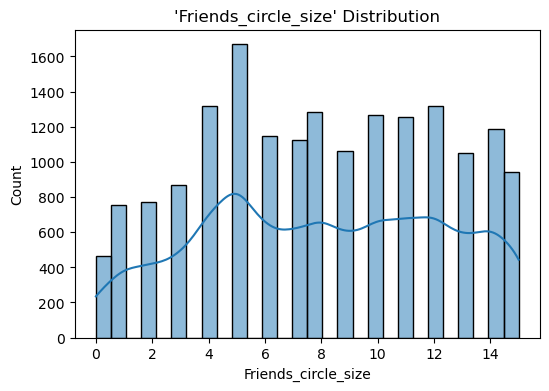

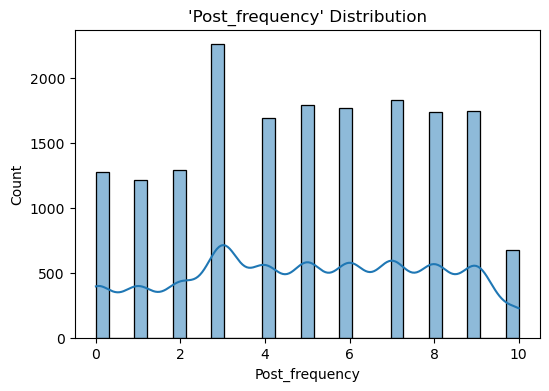

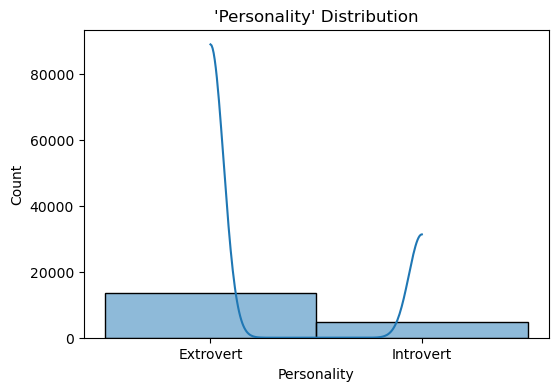

In [25]:
columns = ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Personality']
for col in columns:
    fig = plot_distribution(df, col)
    plt.show()

In [14]:
df.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

In [ ]:
get_overview(df)

In [ ]:
df.describe()

In [ ]:
get_missing_report(df)

In [ ]:
cat_cols = ['Stage_fear', 'Drained_after_socializing']

for col in cat_cols:
    df[f'{col}_ismissing'] = df[col].isna().astype(int)
    df[col].fillna(0, inplace=True)

df = df.replace({'No': 0, 'Yes': 1})

In [ ]:
num_cols = ['Going_outside', 'Post_frequency', 'Time_spent_Alone','Social_event_attendance', 'Friends_circle_size']

for col in num_cols:
    df[f'{col}_isna'] = df[col].isna().astype(int)
    
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

In [ ]:
get_missing_report(df)

In [ ]:
df[num_cols].corr()


In [ ]:
df.drop('Drained_after_socializing', axis=1)

In [ ]:
train_y = df['Personality']
train_X = df.drop('Personality', axis=1)

In [ ]:
df = df.replace({'No': 0, 'Yes': 1})

## 모델 빌드 & 성능 평가

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_regression
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, mean_squared_error

In [ ]:
train_X, test_X, train_y, test_y = train_test_split(train_X, train_y, test_size=0.2, random_state=42)
clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
clf.fit(train_X, train_y)
pred = clf.predict(test_X)
print(f"Classification Accuracy: {accuracy_score(test_y, pred):.4f}")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
%matplotlib inline

cm = confusion_matrix(test_y, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Extrovert', 'Introvert'])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()